Installing the required Python libraries for the project

In [ ]:
!pip install torch gymnasium stable-baselines3 pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 6.4 MB/s eta 0:00:00


Uploading the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload() # Select your CSV file

import pandas as pd
df = pd.read_csv(list(uploaded.keys())[0])
print(df.head())

Saving plasma_etching_synthetic_dataset.csv to plasma_etching_synthetic_dataset (1).csv
   RF_Power_W  Pressure_mTorr  Gas_Flow_sccm  Electrode_Gap_cm  \
0      287.27           78.24          81.31             1.565   
1      575.36           12.21          32.91             3.284   
2      466.00           11.99          93.73             1.741   
3      399.33           39.12          76.02             2.115   
4      178.01           53.98         141.88             1.875   

   Etch_Rate_nm_per_min  Uniformity_pct  Selectivity_ratio  
0                542.89           5.363              8.381  
1                594.94          11.128              3.747  
2                741.37           8.027              5.588  
3                693.34           7.687              5.567  
4                747.63           4.146              8.715  


Neural Network Surrogate Model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 1. Define Surrogate Neural Network
class PlasmaEtchSurrogate(nn.Module):
    def __init__(self, state_dim, action_dim, next_state_dim):
        super(PlasmaEtchSurrogate, self).__init__()
        # Inputs: Current plasma state + dynamic control inputs
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, next_state_dim)
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.net(x)

# Training loop skeleton for your dataset:
# surrogate = PlasmaEtchSurrogate(state_dim=3, action_dim=3, next_state_dim=3)
# optimizer = optim.Adam(surrogate.parameters(), lr=1e-3)
# criterion = nn.MSELoss()
# Loss = criterion(surrogate(states_batch, actions_batch), next_states_batch)

Custom Gymnasium Environment

In [ ]:
import gymnasium as gym
from gymnasium import spaces

class PlasmaEtchEnv(gym.Env):
    """
    State: [Target Depth, Current Depth, Surface Roughness]
    Actions: [RF Power (W), Chamber Pressure (mTorr), Gas Flow Ratio (e.g., SF6/C4F8)]
    """
    def __init__(self, surrogate_model, max_steps=50):
        super(PlasmaEtchEnv, self).__init__()
        self.surrogate = surrogate_model
        self.max_steps = max_steps
        self.current_step = 0

        # Target depth (nm), Current depth (nm), Roughness (nm)
        self.target_depth = 500.0

        # Action space (Normalized between -1.0 and 1.0 for RL stability)
        # Map: [-1, 1] -> [RF Power: 100W-1000W, Pressure: 10mTorr-100mTorr, Gas: 0.1-1.0]
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)

        # State/Observation space
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0]),
            high=np.array([1000.0, 1000.0, 100.0]),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        # State: [Target Depth, Initial Etch Depth, Initial Roughness]
        self.state = np.array([self.target_depth, 0.0, 0.5], dtype=np.float32)
        return self.state, {}

    def step(self, action):
        self.current_step += 1

        # Convert state and action to Tensors for Surrogate model inference
        state_tensor = torch.tensor(self.state, dtype=torch.float32)
        action_tensor = torch.tensor(action, dtype=torch.float32)

        with torch.no_grad():
            # Model predicts the delta/next state features
            next_state = self.surrogate(state_tensor, action_tensor).numpy()

        self.state = next_state
        current_depth = self.state[1]
        roughness = self.state[2]

        # Reward formulation: Reward depth accuracy, penalize surface roughness and step count
        depth_error = abs(self.target_depth - current_depth)
        reward = - (depth_error * 0.1) - (roughness * 2.0)

        # Termination conditions
        terminated = bool(depth_error < 5.0)  # Reached target within margin
        truncated = bool(self.current_step >= self.max_steps)

        if terminated:
            reward += 100.0  # Success bonus

        return self.state, reward, terminated, truncated, {}

Reinforcement Learning Agent using Soft Actor-Critic (SAC) or Proximal Policy Optimization (PPO)

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch

class PlasmaEtchEnv(gym.Env):
    def __init__(self, surrogate_model, max_steps=50):
        super(PlasmaEtchEnv, self).__init__()
        self.surrogate = surrogate_model
        self.max_steps = max_steps
        self.current_step = 0
        self.target_depth = 500.0

        # Explicitly declare float32 arrays for low and high bounds
        self.action_space = spaces.Box(
            low=np.array([-1.0, -1.0, -1.0], dtype=np.float32),
            high=np.array([1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([1000.0, 1000.0, 100.0], dtype=np.float32),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0

        # Force float32 type matching the observation_space
        self.state = np.array([self.target_depth, 0.0, 0.5], dtype=np.float32)
        return self.state, {}

    def step(self, action):
        self.current_step += 1

        # Ensure action input is float32
        action = np.array(action, dtype=np.float32)

        state_tensor = torch.tensor(self.state, dtype=torch.float32)
        action_tensor = torch.tensor(action, dtype=torch.float32)

        with torch.no_grad():
            next_state = self.surrogate(state_tensor, action_tensor).numpy()

        # Explicitly cast model output back to float32 NumPy array
        self.state = np.array(next_state, dtype=np.float32)
        current_depth = self.state[1]
        roughness = self.state[2]

        depth_error = float(abs(self.target_depth - current_depth))
        reward = float(-(depth_error * 0.1) - (roughness * 2.0))

        terminated = bool(depth_error < 5.0)
        truncated = bool(self.current_step >= self.max_steps)

        if terminated:
            reward += 100.0

        return self.state, reward, terminated, truncated, {}

Training RL agent...


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training Complete!

Step  | Depth (nm)   | Roughness  | Action (RF, Press, Gas)  
------------------------------------------------------------
1     | 16.18        | 0.45       | [0.89, 0.02, -0.04]      
2     | 32.36        | 0.48       | [0.89, 0.03, -0.04]      
3     | 48.54        | 0.40       | [0.89, 0.03, -0.04]      
4     | 64.72        | 0.42       | [0.89, 0.03, -0.04]      
5     | 80.93        | 0.37       | [0.89, 0.01, -0.05]      
6     | 97.16        | 0.30       | [0.90, -0.02, -0.06]     
7     | 113.32       | 0.25       | [0.89, -0.01, -0.04]     
8     | 129.45       | 0.28       | [0.88, -0.02, -0.03]     
9     | 145.56       | 0.30       | [0.88, -0.02, -0.03]     
10    | 161.60       | 0.22       | [0.87, -0.01, -0.01]     
11    | 177.55       | 0.20       | [0.86, -0.02, 0.01]      
12    | 193.41       | 0.18       | [0.85, -0.02, 0.02]      
13    | 209.15       | 0.10       | [0.83, -0.03, 0.03]      
14    | 224.76       | 0.12       | [0.81, -0.04, 0

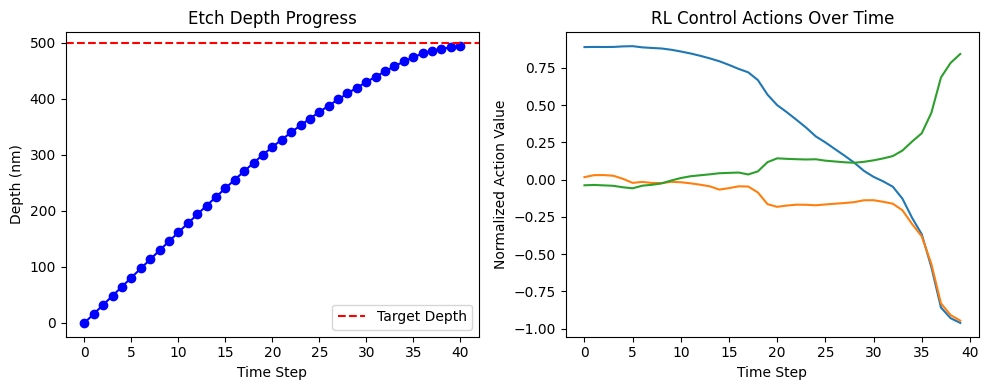

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
import matplotlib.pyplot as plt

# 1. Dummy Trained Surrogate Model
class DummySurrogate(nn.Module):
    def forward(self, state, action):
        # Simulates material removal: depth increases based on RF Power (action[0])
        rf_power = (action[0] + 1.0) / 2.0  # scale [-1, 1] to [0, 1]

        target_depth = state[0]
        current_depth = state[1] + (rf_power * 15.0) + 2.0
        roughness = max(0.1, state[2] + np.random.normal(0, 0.05))

        return torch.tensor([target_depth, current_depth, roughness], dtype=torch.float32)

# 2. Gymnasium Plasma Etch Environment
class PlasmaEtchEnv(gym.Env):
    def __init__(self, surrogate_model, max_steps=40):
        super(PlasmaEtchEnv, self).__init__()
        self.surrogate = surrogate_model
        self.max_steps = max_steps
        self.current_step = 0
        self.target_depth = 500.0

        self.action_space = spaces.Box(
            low=np.array([-1.0, -1.0, -1.0], dtype=np.float32),
            high=np.array([1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32
        )
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([1000.0, 1000.0, 100.0], dtype=np.float32),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.state = np.array([self.target_depth, 0.0, 0.5], dtype=np.float32)
        return self.state, {}

    def step(self, action):
        self.current_step += 1
        action = np.array(action, dtype=np.float32)

        with torch.no_grad():
            next_state = self.surrogate(
                torch.tensor(self.state, dtype=torch.float32),
                torch.tensor(action, dtype=torch.float32)
            ).numpy()

        self.state = np.array(next_state, dtype=np.float32)
        depth_error = float(abs(self.target_depth - self.state[1]))
        roughness = float(self.state[2])

        reward = float(-(depth_error * 0.1) - (roughness * 2.0))
        terminated = bool(depth_error < 5.0)
        truncated = bool(self.current_step >= self.max_steps)

        if terminated:
            reward += 100.0

        return self.state, reward, terminated, truncated, {}

# 3. Train the RL Agent
surrogate = DummySurrogate()
env = PlasmaEtchEnv(surrogate_model=surrogate)

model = SAC("MlpPolicy", env, verbose=0, learning_rate=3e-4)
print("Training RL agent...")
model.learn(total_timesteps=10000)
print("Training Complete!\n")

# 4. Evaluation Loop & Printing Trajectory Results
obs, info = env.reset()
done = False
step = 0

depths = [obs[1]]
actions_history = []

print(f"{'Step':<5} | {'Depth (nm)':<12} | {'Roughness':<10} | {'Action (RF, Press, Gas)':<25}")
print("-" * 60)

while not done:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    step += 1

    depths.append(obs[1])
    actions_history.append(action)

    act_str = f"[{action[0]:.2f}, {action[1]:.2f}, {action[2]:.2f}]"
    print(f"{step:<5} | {obs[1]:<12.2f} | {obs[2]:<10.2f} | {act_str:<25}")

# 5. Plot the Results
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(depths, marker='o', color='b')
plt.axhline(y=500.0, color='r', linestyle='--', label='Target Depth')
plt.title('Etch Depth Progress')
plt.xlabel('Time Step')
plt.ylabel('Depth (nm)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(actions_history)
plt.title('RL Control Actions Over Time')
plt.xlabel('Time Step')
plt.ylabel('Normalized Action Value')
plt.tight_layout()
plt.show()